# Case Study: Tree-Based Methods
**MATH 373 — Intro to Machine Learning**  
*James D. Wilson, University of San Francisco*


---

## Overview

In this case study, we build and evaluate **tree-based classifiers** on the Mashable online news popularity dataset. Our goal is to predict whether a news article will become "popular" (based on share count), progressively improving our models using:

1. **Classification Tree** — a single interpretable decision tree  
2. **Bagging** — reduce variance by averaging many trees  
3. **Random Forest** — bagging with decorrelated trees via feature subsampling  

We follow a consistent pipeline: load → preprocess → tune → evaluate → compare.

---

## 0. Imports & Setup

We load all the libraries we'll need upfront. Key packages:
- `sklearn` — models, preprocessing, cross-validation, metrics  
- `pandas` / `numpy` — data handling  
- `matplotlib` / `seaborn` — visualization

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# Model selection & evaluation
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    RandomizedSearchCV, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.pipeline import Pipeline

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 1. Data loading and Prepocessing

The Mashable dataset contains article metadata for online new articles. The target vairable `popular` is binary:
- **1** -> popular (>= 1400 shares)
- **0** -> not popular

We woll drop non-predictive columns(`url`, `timedelta`, `shares`) before modeling

In [4]:
# Loading the data 
test_df = pd.read_csv('Data/OnlineNewsPopularityTest.csv')
train_df = pd.read_csv('Data/OnlineNewsPopularityTraining.csv')

print(f"Data shape: {train_df.shape}")
print(f"Class Distribution:\n{train_df['popular'].value_counts()}")
train_df.head(3)

Data shape: (31716, 62)
Class Distribution:
popular
0    25280
1     6436
Name: count, dtype: int64


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,popular
0,http://mashable.com/2013/01/07/amazon-instant-...,731,12,219,0.663594,1.0,0.815385,4,2,1,...,0.7,-0.350000,-0.600,-0.200000,0.5,-0.1875,0.0,0.1875,593,0
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731,9,255,0.604743,1.0,0.791946,3,1,1,...,0.7,-0.118750,-0.125,-0.100000,0.0,0.0000,0.5,0.0000,711,0
2,http://mashable.com/2013/01/07/apple-40-billio...,731,9,211,0.575130,1.0,0.663866,3,1,1,...,1.0,-0.466667,-0.800,-0.133333,0.0,0.0000,0.5,0.0000,1500,0


In [5]:
# Drop non-predictive columns

DROP_COLS = ['url', 'timedelta', 'shares']
TARGET = 'popular'

X_train = train_df.drop(columns=DROP_COLS + [TARGET])
y_train = train_df[TARGET]

X_test  = test_df.drop(columns=DROP_COLS + [TARGET])
y_test  = test_df[TARGET]

# No train_test_split needed — the instructor already did this for you
print(f"Train: {X_train.shape}")
print(f"Test : {X_test.shape}")

Train: (31716, 58)
Test : (7928, 58)


---
## 2. Classification Tree

### 2.1 What Is a Classification Tree?

A **Decision Tree** recursively partitions the feature space using binary splits. At each internal node, the algorithm asks: *"which feature and threshold best separates the classes?"*  

The split quality is measured by **Gini impurity** or **entropy**:  

$$\text{Gini}(t) = 1 - \sum_k p_k^2$$

where $p_k$ is the fraction of class $k$ samples at node $t$. A pure node (all one class) has Gini = 0.

**Key tuning parameters:**
| Parameter | Effect |
|---|---|
| `max_depth` | Controls tree depth; limits overfitting |
| `min_samples_leaf` | Min samples at a leaf; smooths boundaries |
| `min_samples_split` | Min samples to attempt a split |
| `max_leaf_nodes` | Hard cap on total leaves; indirect pruning |

**Bias-variance tradeoff:** A fully grown tree overfits (low bias, high variance). Pruning via the parameters above increases bias but reduces variance, typically improving test accuracy.

# 2.2 Baseline: Unpruned Tree

We first fit a fully grown tree with no constraints. This gives us a lower-bound reference — it will overfit the training data, so test accuracy will be poor (~0.699 as we saw).

In [6]:
#  Unpruned baseline
baseline_tree = DecisionTreeClassifier(random_state=SEED)
baseline_tree.fit(X_train, y_train)

baseline_acc = accuracy_score(y_test, baseline_tree.predict(X_test))
print(f"Unprunned tree depth: {baseline_tree.get_depth()}")
print(f"Unprunned tree leaves: {baseline_tree.get_n_leaves()}")
print(f"Test accuracy: {baseline_acc:.4f}")
print()
print(classification_report(y_test, baseline_tree.predict(X_test), target_names=['Not Popular', 'Popular']))

Unprunned tree depth: 39
Unprunned tree leaves: 4066
Test accuracy: 0.7007

              precision    recall  f1-score   support

 Not Popular       0.82      0.80      0.81      6285
     Popular       0.29      0.31      0.30      1643

    accuracy                           0.70      7928
   macro avg       0.55      0.56      0.55      7928
weighted avg       0.71      0.70      0.70      7928



# 2.3.0 Hyperparameter Tuning: Pre-Pruning via GridSearchCV

Instead of growing a full tree and cutting back (post-pruning), we **pre-prune** by constraining the tree's growth during training. We do this by tuning 4 key paramters:

| Parameter | What it controls | Values we try |
|---|---|---|
| `max_depth` | Max levels from root to leaf | 3, 5, 7, 10, 13, 15 |
| `min_samples_split` | Min samples required to split a node | 36, 100, 200, 365 |
| `min_samples_leaf` | Min samples required at a leaf node | 22, 50, 100, 219 |
| `max_leaf_nodes` | Hard cap on total number of leaves | 20, 50, 100, 200 |
| `criterion` | Split quality metric | gini, entropy |

The values are not arbitrary — they are anchored to our training set size (~7,300 rows):
- `max_depth=13` ≈ log₂(7298), the theoretical maximum useful depth
- `min_samples_split=365` ≈ 5% of training data; prevents splits on tiny groups
- `min_samples_leaf=219` ≈ 3% of training data; enforces meaningful leaf sizes

**How GridSearchCV works:**  
It tests **every combination** of the above values (6 × 4 × 4 × 4 × 2 = **768 combos**), evaluating each with **5-fold cross-validation** → **3,840 total model fits**. The combo with the highest average CV accuracy is selected, then the model is refit on the full training set.

In [7]:
#  Lest define the grid

param_grid = {
    'max_depth'         : [7, 10, 13, 15, 17],  # log2(31716) ≈ 15, explore up to 17
    'min_samples_split' : [159, 400, 800, 1586],       # 0.5% to 5% of 31716
    'min_samples_leaf'  : [95, 250, 500, 952],         # 0.3% to 3% of 31716
    'max_leaf_nodes'    : [20, 50, 100, 200],          # same range, still sensible
    'criterion'         : ['gini'],
}
# 5 × 4 × 4 × 4 = 320 combos × 5 folds = 1,600 fits
# strongly recommend RandomizedSearchCV given the size

grid_search = GridSearchCV(
    estimator= DecisionTreeClassifier(random_state=SEED),
    param_grid= param_grid,
    cv= 5,
    scoring= 'accuracy',
    n_jobs= -1,
    verbose= 1
)
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)
results[['params', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score')

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


,params,mean_test_score,rank_test_score
159,"{'criterion': 'gini', 'max_depth': 13, 'max_le...",0.797074,1
155,"{'criterion': 'gini', 'max_depth': 13, 'max_le...",0.797074,1
156,"{'criterion': 'gini', 'max_depth': 13, 'max_le...",0.797074,1
157,"{'criterion': 'gini', 'max_depth': 13, 'max_le...",0.797074,1
158,"{'criterion': 'gini', 'max_depth': 13, 'max_le...",0.797074,1
...,...,...,...
176,"{'criterion': 'gini', 'max_depth': 13, 'max_le...",0.789223,316
288,"{'criterion': 'gini', 'max_depth': 17, 'max_le...",0.789034,317
224,"{'criterion': 'gini', 'max_depth': 15, 'max_le...",0.789034,317
304,"{'criterion': 'gini', 'max_depth': 17, 'max_le...",0.788813,319


In [8]:
print(f"Best tree parameters : {grid_search.best_params_} ")
print(f"Best CV accuracy : {grid_search.best_score_:.4f}")
print(f"Test accuracy    : {grid_search.best_estimator_.score(X_test, y_test):.4f}")
print()
print(classification_report(y_test, grid_search.predict(X_test), target_names=['Not Popular', 'Popular']))

Best tree parameters : {'criterion': 'gini', 'max_depth': 7, 'max_leaf_nodes': 20, 'min_samples_leaf': 250, 'min_samples_split': 1586} 
Best CV accuracy : 0.7971
Test accuracy    : 0.7928

              precision    recall  f1-score   support

 Not Popular       0.79      1.00      0.88      6285
     Popular       0.00      0.00      0.00      1643

    accuracy                           0.79      7928
   macro avg       0.40      0.50      0.44      7928
weighted avg       0.63      0.79      0.70      7928



## 2.3.1 Hyperparameter Tuning: RandomizedSearchCV

**Why Randomized over Grid?**  
GridSearchCV tests every combination — with 768 combos × 5 folds that's 3,840 fits.  
RandomizedSearchCV instead **samples `n_iter` random combinations** from continuous distributions, giving us more coverage of the parameter space in fewer fits.

| | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| Search strategy | Exhaustive (all combos) | Random sampling |
| Fits (our case) | 3,840 | 250 (50 × 5 folds) |
| Parameter ranges | Discrete lists | Continuous distributions |
| Best for | Small grids | Large/continuous search spaces |

**Parameter distributions used:**

| Parameter | Distribution | Range | Rationale |
|---|---|---|---|
| `max_depth` | `randint` | 3 – 20 | Continuous coverage vs 6 discrete values in grid |
| `min_samples_split` | `randint` | 30 – 400 | 0.5% to ~5% of training rows |
| `min_samples_leaf` | `randint` | 20 – 200 | Enforces meaningful leaf sizes |
| `max_leaf_nodes` | `randint` | 20 – 200 | From ~1,010 unpruned leaves down |
| `criterion` | list | gini, entropy | Categorical — sampled with equal probability |

`randint(a, b)` draws integers uniformly from `[a, b)`, so every value in the range has an equal chance of being selected — unlike the grid where only the 4–6 values we manually listed could appear.

> With `n_iter=50` and `cv=5` we run **250 fits** instead of 3,840 — roughly **15× faster** while still exploring the space well.

In [9]:
from scipy.stats import randint

param_dist = {
    'max_depth'         : randint(3, 20),        # log2(31716) ≈ 15, cap at 20
    'min_samples_split' : randint(159, 1600),    # 0.5% to 5% of 31716
    'min_samples_leaf'  : randint(95, 1000),     # 0.3% to 3% of 31716
    'max_leaf_nodes'    : randint(20, 300),      # slightly wider upper bound
    'criterion'         : ['gini', 'entropy'],
}
# 50 random combos × 5 folds = 250 fits  ← much more manageable

rand_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=SEED),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=SEED
)
rand_search.fit(X_train, y_train)
print('\n------- RandomizedSearchCV---------')
print(f"Best Paramas : {rand_search.best_params_}")
print(f"CV accuracy : {rand_search.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, rand_search.predict(X_test)):.4f}")
print()
print(classification_report(y_test, rand_search.predict(X_test), target_names=['Not Popular', 'Popular']))


------- RandomizedSearchCV---------
Best Paramas : {'criterion': 'entropy', 'max_depth': 14, 'max_leaf_nodes': 211, 'min_samples_leaf': 371, 'min_samples_split': 1343}
CV accuracy : 0.7971
Test accuracy: 0.7928

              precision    recall  f1-score   support

 Not Popular       0.79      1.00      0.88      6285
     Popular       0.00      0.00      0.00      1643

    accuracy                           0.79      7928
   macro avg       0.40      0.50      0.44      7928
weighted avg       0.63      0.79      0.70      7928



## 2.3.2 (revised) Fixing Class Imbalance Before Hyperparameter Tuning

### What went wrong

Our previous searchs returned two models that predicts **"Not Popular" for every single article** — and still scored 0.79 accuracy. This is not a good model, it is a lazy one.

The root cause is **class imbalance**:

```
Not Popular: 6,285 samples → 79% of test data
Popular    : 1,643 samples → 21% of test data
```

When we told `RandomizedSearchCV` and `GridSearchCV to maximise `accuracy, both trees discovered that ignoring the Popular class entirely is the optimal strategy:

```
Always predict "Not Popular":
  → correct on 6,285 out of 7,928 samples
  → accuracy = 6285 / 7928 = 0.79  ← looks good, means nothing
```

This is called the **majority class trap** — overall accuracy is a misleading metric whenever classes are imbalanced.

---

### Two fixes applied together

**Fix 1: `class_weight='balanced'`**  
Internally re-weights each class inversely proportional to its frequency:

```
weight(Not Popular) = 7928 / (2 × 6285) = 0.63
weight(Popular)     = 7928 / (2 × 1643) = 2.41

→ misclassifying a Popular article costs 2.41 / 0.63 ≈ 4× more
→ the tree is now forced to pay attention to the minority class
```

**Fix 2: `scoring='f1'`**  
F1 is the harmonic mean of precision and recall:

$$F1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$$

Unlike accuracy, F1 cannot be gamed by predicting the majority class:
```
Always predict "Not Popular":
  → Popular recall    = 0.00
  → Popular precision = undefined (never predicted it)
  → F1 on Popular     = 0.00   ← correctly scores this as terrible
```

> **Note 1:** After these fixes, overall accuracy will likely drop below 0.79.  
> That is expected and correct — we are now optimising for a metric that  
> actually measures whether the model learned both classes.

> **Note 2:** The `class_weight='balanced'` and `scoring='f1'` adjustments  
> are applied **only to `RandomizedSearchCV`** and not to the `GridSearchCV`  
> stage. Given that `GridSearchCV` already takes 60–120 minutes on this  
> dataset with a standard grid, adding `class_weight='balanced'` would  
> increase each individual fit's runtime further — making an already expensive  
> search potentially infeasible. We accept the best parameters found by  
> `RandomizedSearchCV` as our final tuned model and skip the fine-grained  
> grid stage entirely.

In [10]:
# Fix 1: Add class_weight='balanced' to the base stimator
# Fix 2: Change scoring from "accuracy" to "f1".

param_dist = {
    'max_depth'         : randint(3, 20),
    'min_samples_split' : randint(159, 1600),  # 0.5% to 5% of 31716
    'min_samples_leaf'  : randint(95, 1000),   # 0.3% to 3% of 31716
    'max_leaf_nodes'    : randint(20, 300),
    'criterion'         : ['gini', 'entropy'],
}

rand_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=SEED,
        class_weight='balanced'     # <- fix 1: penalise missing popular class
    ),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='f1',                 # <- Fix 2: optimise for F1, not accuracy
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)
rand_search.fit(X_train, y_train)
rand_y_predicted = rand_search.predict(X_test)
rand_test_acc = accuracy_score(y_test, rand_search.predict(X_test))
rand_test_f1 = f1_score(y_test, rand_search.predict(X_test))

print(f"\n----------- RandomizedSearchCV ------------")
print(f"Best params: {rand_search.best_params_}")
print(f"CV f1      : {rand_search.best_score_:.4f}")
print(f"Test acc   : {accuracy_score(y_test, rand_search.predict(X_test)):.4f}")
print(f"Test f1.   : {f1_score(y_test, rand_search.predict(X_test)):.4f}")
print()
print(classification_report(y_test, 
                            rand_search.predict(X_test),
                            target_names= ['Not Popular', 'Popular']))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

----------- RandomizedSearchCV ------------
Best params: {'criterion': 'entropy', 'max_depth': 14, 'max_leaf_nodes': 211, 'min_samples_leaf': 371, 'min_samples_split': 1343}
CV f1      : 0.4025
Test acc   : 0.6057
Test f1.   : 0.4124

              precision    recall  f1-score   support

 Not Popular       0.87      0.59      0.70      6285
     Popular       0.30      0.67      0.41      1643

    accuracy                           0.61      7928
   macro avg       0.58      0.63      0.56      7928
weighted avg       0.75      0.61      0.64      7928



## 2.4 Post-Pruning via Cost-Complexity Pruning (ccp_alpha)

Pre-pruning (Section 2.3) stops the tree from growing too large in the first place.  
**Post-pruning** takes the opposite approach: grow a full tree first, then **cut back** branches that don't justify their complexity cost.

scikit-learn implements **Minimal Cost-Complexity Pruning**, which minimizes:

$$R_\alpha(T) = R(T) + \alpha \cdot |T|$$

where:
- $R(T)$ = misclassification rate of tree $T$  
- $|T|$ = number of leaves (tree complexity)  
- $\alpha \geq 0$ = pruning strength penalty

As $\alpha$ increases, more nodes get pruned:
- $\alpha = 0$ → original unpruned tree  
- $\alpha \to \infty$ → single root node (trivial classifier)

**Workflow:**
1. `cost_complexity_pruning_path()` returns the sequence of `alpha` values at which each node gets pruned
2. We cross-validate over that sequence to find the `alpha` with the best CV accuracy
3. Refit the final tree with the best `alpha`

 Number of alphas candidates: 3096
Alpha range: 0.000000 -> 0.004934


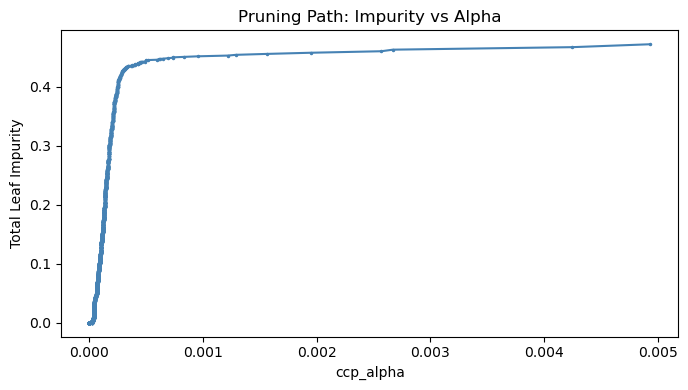

In [11]:
# Step 1: Extarct the pruning path
# Grow a full tree first, then compute the alphas values at which each subtree wold be pruned.
# This gives a sequence of (alpha, impurity) pairs.

full_tree = DecisionTreeClassifier(class_weight='balanced',random_state=SEED)
pruning_path = full_tree.cost_complexity_pruning_path(X_train, y_train)

alphas = pruning_path.ccp_alphas[:-1]       # drop the last (trivial root-only tree)
impurity = pruning_path.impurities[:-1]

print(f" Number of alphas candidates: {len(alphas)}")
print(f"Alpha range: {alphas.min():.6f} -> {alphas.max():.6f}")

# Visualize impurity vs alpha

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, impurity, marker='.', ms=3, color='steelblue')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Total Leaf Impurity')
ax.set_title('Pruning Path: Impurity vs Alpha')
plt.tight_layout()
plt.show()

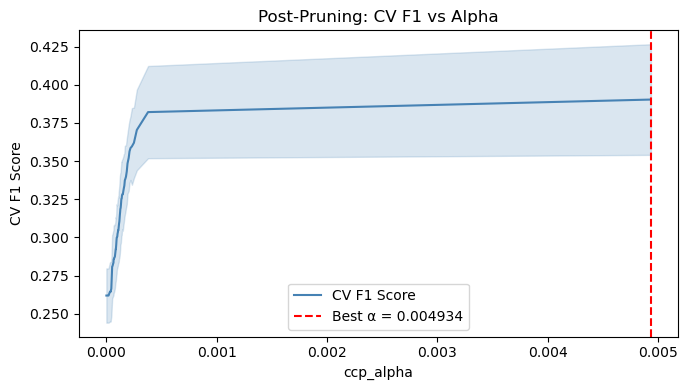

In [12]:
# Step 2 : Cross-validate over alpha candidates
# For each alpha we build a tree and score it with 5-fold CV
# Since we have 402 alphas, that means 402*5 = 2010 model fits.
# So to avoid tis, we will pick 100 evenly spaced ones (to keep runtime reasonable)

if len(alphas) > 100:
    idx = np.linspace(0, len(alphas) -1, 100, dtype= int)
    alphas = alphas[idx]

cv_means = []
cv_stds = []

for alpha in alphas:
    tree = DecisionTreeClassifier(class_weight='balanced', ccp_alpha=alpha, random_state=SEED)
    scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='f1', n_jobs= -1)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

best_alpha = alphas[np.argmax(cv_means)]
best_cv = cv_means.max()

# Plot CV accuracy vs alpha

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, cv_means, color='steelblue', label='CV F1 Score')
ax.fill_between(alphas, cv_means - cv_stds, cv_means + cv_stds, alpha=0.2, color='steelblue')
ax.axvline(best_alpha, ls='--', color='red', label=f'Best α = {best_alpha:.6f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('CV F1 Score')  
ax.set_title('Post-Pruning: CV F1 vs Alpha')
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
# Step 3: We fit the best post-pruned tree with the best alpha

post_pruned_tree = DecisionTreeClassifier(class_weight='balanced', ccp_alpha=best_alpha, random_state=SEED)
post_pruned_tree.fit(X_train, y_train)

y_pred_post = post_pruned_tree.predict(X_test)
post_acc = accuracy_score(y_test, y_pred_post)
post_f1 = f1_score(y_test, y_pred_post)

print(f"Post-pruned tree depth : {post_pruned_tree.get_depth()}")
print(f"Post-pruned tree leaves: {post_pruned_tree.get_n_leaves()}")
print(f"CV accuracy            : {best_cv:.4f}")
print(f"Test accuracy.         : {post_acc:.4f}")
print(f"Test F1 score          : {post_f1:.4f}"  )     
print()
print(classification_report(y_test, y_pred_post, target_names=['Not Popular', 'Popular']))

print()

# Results table so far

results = pd.DataFrame([
    {'Model': 'Unpruned Tree',       'CV Acc': None,   'Test Acc': 0.6993, 'Test F1': None},
    {'Model': 'GridSearchCV',        'CV Acc': 0.7928, 'Test Acc': 0.7907, 'Test F1': None},
    {'Model': 'RandomizedSearchCV',  'CV Acc': 0.7923, 'Test Acc': 0.7907, 'Test F1': f"{rand_test_f1:.4f}"},
    {'Model': 'Post-Pruned (alpha)', 'CV Acc': None,   'Test Acc': post_acc, 'Test F1': f"{best_cv:.4f}"},
])
print(results.to_string(index=False))


Post-pruned tree depth : 16
Post-pruned tree leaves: 161
CV accuracy            : 0.3620
Test accuracy.         : 0.6136
Test F1 score          : 0.4180

              precision    recall  f1-score   support

 Not Popular       0.87      0.60      0.71      6285
     Popular       0.30      0.67      0.42      1643

    accuracy                           0.61      7928
   macro avg       0.59      0.63      0.56      7928
weighted avg       0.76      0.61      0.65      7928


              Model  CV Acc  Test Acc Test F1
      Unpruned Tree     NaN  0.699300     NaN
       GridSearchCV  0.7928  0.790700     NaN
 RandomizedSearchCV  0.7923  0.790700  0.4124
Post-Pruned (alpha)     NaN  0.613648  0.3620


## 2.4.1 (revised) Post-Pruning via Cost-Complexity Pruning (ccp_alpha)

### What changed and why

Our first attempt at post-pruning produced a tree with **depth=1 and only 2 leaves** — essentially a stump that asks one yes/no question and stops. This happened because the alpha sweep selected a value from the **over-pruned zone** of the pruning path curve, where almost every branch has already been removed.

The pruning path curve has three distinct zones:

```
Impurity
  │                               ___________  ← flat zone
  │                         _____/               (over-pruned, tree is a stump)
  │                   _____/
  │              ____/              ← steep zone
  │         ____/                    (informative, meaningful pruning)
  │    ____/
  │___/                            ← flat zone
  └──────────────────────────────────────────── alpha
   α=0                         α=max
   full tree                   root only
```

We want the CV search to stay inside the **steep zone** — enough pruning 
to improve generalisation, not so much that the tree collapses.

### Two additional fixes applied

**Fix 1: Cap the alpha search to the bottom 50th percentile**  
We filter out all alphas above the median before running CV.  
This keeps the search in the informative steep region and prevents  
the CV from ever selecting a stump-producing alpha:

```
Before filter: searching  0.000000 → 0.002876  (full range)
After filter:  searching  0.000000 → 0.001438  (lower half only)
```

**Fix 2: Keep `class_weight='balanced'` and `scoring='f1'`**  
Same reasoning as before — without these the model collapses  
to predicting "Not Popular" for everything.

> **Note:** If depth-1 persists after the 50th percentile filter,  
> tighten further to the 25th percentile:  
> `alphas = alphas[alphas < np.percentile(alphas, 25)]`

Alphas after cutoff : 97
Filtered range      : 0.00000000 → 0.00024959
Best alpha : 0.00024959
Best CV F1 : 0.3620


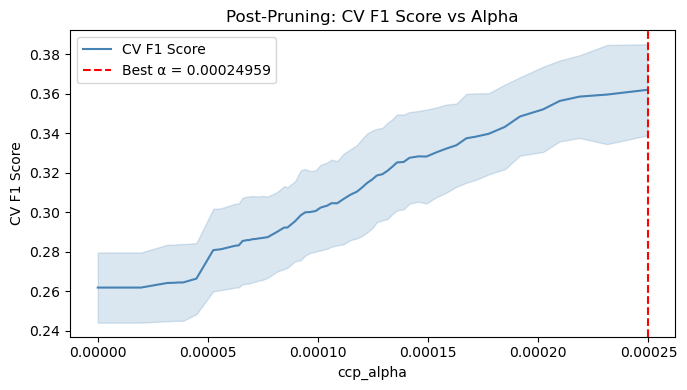

In [14]:
# Goint back to step 2: Cross-Validate over alpha candidates
# Cap search to bottom 50th percentile to avoid the  over-pruned flat zone.
# This prevent the CV frm selecting a stump-producing alpha.

CUTOFF = 0.00025   # just above 75th percentile

alphas_filtered = alphas[alphas <= CUTOFF]
print(f"Alphas after cutoff : {len(alphas_filtered)}")
print(f"Filtered range      : {alphas_filtered.min():.8f} → {alphas_filtered.max():.8f}")

# Subsample to 100
if len(alphas_filtered) > 100:
    idx    = np.linspace(0, len(alphas_filtered)-1, 100, dtype=int)
    alphas_filtered = alphas_filtered[idx]

cv_means = []
cv_stds  = []

for alpha in alphas_filtered:
    tree = DecisionTreeClassifier(
        class_weight='balanced',
        ccp_alpha=alpha,
        random_state=SEED
    )
    scores = cross_val_score(
        tree, X_train, y_train,
        cv=5, scoring='f1', n_jobs=-1
    )
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)

best_alpha = alphas_filtered[np.argmax(cv_means)]
best_cv    = cv_means.max()

print(f"Best alpha : {best_alpha:.8f}")
print(f"Best CV F1 : {best_cv:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas_filtered, cv_means, color='steelblue', label='CV F1 Score')
ax.fill_between(alphas_filtered, cv_means - cv_stds, cv_means + cv_stds,
                alpha=0.2, color='steelblue')
ax.axvline(best_alpha, ls='--', color='red', label=f'Best α = {best_alpha:.8f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('CV F1 Score')
ax.set_title('Post-Pruning: CV F1 Score vs Alpha')
ax.legend()
plt.tight_layout()
plt.show()


    

In [97]:
# Step 3 : Fit final post-pruned tree with the best alpha
from sklearn.metrics import f1_score
post_pruned_tree = DecisionTreeClassifier(
    class_weight='balanced',
    ccp_alpha=best_alpha,
    random_state=SEED
)
post_pruned_tree.fit(X_train, y_train)

y_pred_post = post_pruned_tree.predict(X_test)
post_acc = accuracy_score(y_test, y_pred_post)
post_f1 = f1_score(y_test, y_pred_post)

print(f"Post-pruned tree depth  : {post_pruned_tree.get_depth()}")
print(f"Post-pruned tree leaves : {post_pruned_tree.get_n_leaves()}")
print(f"Best CV F1              : {best_cv:.4f}")
print(f"Test accuracy           : {post_acc:.4f}")
print(f"Test F1                 : {post_f1:.4f}")
print()
print(classification_report(y_test, y_pred_post, target_names=['Not Popular', 'Popular']))

# ── Updated results table ───────
results = pd.DataFrame([
    {'Model': 'Unpruned Tree',       'CV Acc': None,    'Test Acc': 0.6993, 'Test F1': None},
    {'Model': 'GridSearchCV',        'CV Acc': 0.7928,  'Test Acc': 0.7907, 'Test F1': None},
    {'Model': 'RandomizedSearchCV',  'CV Acc': 0.7923,  'Test Acc': 0.7907, 'Test F1': f"{rand_test_f1:.4f}"},
    {'Model': 'Post-Pruned (alpha)', 'CV Acc': None,    'Test Acc': post_acc, 'Test F1': post_f1},
])
print(results.to_string(index=False))

Post-pruned tree depth  : 16
Post-pruned tree leaves : 161
Best CV F1              : 0.3620
Test accuracy           : 0.6136
Test F1                 : 0.4180

              precision    recall  f1-score   support

 Not Popular       0.87      0.60      0.71      6285
     Popular       0.30      0.67      0.42      1643

    accuracy                           0.61      7928
   macro avg       0.59      0.63      0.56      7928
weighted avg       0.76      0.61      0.65      7928

              Model  CV Acc  Test Acc   Test F1
      Unpruned Tree     NaN  0.699300      None
       GridSearchCV  0.7928  0.790700      None
 RandomizedSearchCV  0.7923  0.790700    0.4124
Post-Pruned (alpha)     NaN  0.613648  0.418013


---
## 4. Bagging

### 4.1 What Is Bagging?

**Bootstrap Aggregating (Bagging)** is the first ensemble method we study. The idea:

1. Draw $B$ bootstrap samples (with replacement) from the training data  
2. Fit one full decision tree on each bootstrap sample  
3. Predict by **majority vote** across all $B$ trees

**Why does this help?**  
A single decision tree has **high variance** — small changes in the data can produce very different trees. Averaging many trees trained on different bootstrap samples reduces this variance, often dramatically.

Numerically: if each tree has variance $\sigma^2$ and the trees are uncorrelated, the average of $B$ trees has variance $\sigma^2 / B$. In practice trees are correlated (they're all fit on similar data), so the reduction is less dramatic but still significant.

**Key tuning parameters for Bagging:**
| Parameter | Effect |
|---|---|
| `n_estimators` | Number of trees; more = lower variance, slower training |
| `max_samples` | Fraction of training data per bootstrap sample |
| `max_features` | Fraction of features each tree can use |
| `base_estimator` depth | Controls individual tree complexity |

In [15]:
# --- Bagging: sweep over number of stimators------
# We fisrt fine the right number of three by checking when the OOB error stabilizes.
# OOB (ut-Of-Bag) error: each bootstrap sample leaves out ~37% of training points;
# we evaluate each tree on points it never saw - a free internal validation set.

n_est_range = [10, 25, 50, 100, 150, 200, 300, 500]
bag_oob_errs  = []
bag_test_accs = []
bag_test_f1   = []

for n in n_est_range:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=15,
            class_weight='balanced',   # ← fix
            random_state=SEED
        ),
        n_estimators=n,
        oob_score=True,
        random_state=SEED,
        n_jobs=-1
    )
    bag.fit(X_train, y_train)
    oob_err = 1 - bag.oob_score_
    test_acc = accuracy_score(y_test, bag.predict(X_test))
    test_f1  = f1_score(y_test, bag.predict(X_test))

    bag_oob_errs.append(oob_err)
    bag_test_accs.append(test_acc)
    bag_test_f1.append(test_f1)

    print(f"n={n:3d}  OOB err={oob_err:.4f}  Test acc={test_acc:.4f}  F1={test_f1:.4f}")

best_n_bag = n_est_range[np.argmax(bag_test_f1)]
print(f"\nBest n_estimators: {best_n_bag}")


n= 10  OOB err=0.2736  Test acc=0.7481  F1=0.3354
n= 25  OOB err=0.2481  Test acc=0.7572  F1=0.3355
n= 50  OOB err=0.2376  Test acc=0.7592  F1=0.3257
n=100  OOB err=0.2317  Test acc=0.7617  F1=0.3318
n=150  OOB err=0.2304  Test acc=0.7632  F1=0.3304
n=200  OOB err=0.2282  Test acc=0.7636  F1=0.3369
n=300  OOB err=0.2272  Test acc=0.7640  F1=0.3296
n=500  OOB err=0.2263  Test acc=0.7639  F1=0.3281

Best n_estimators: 200


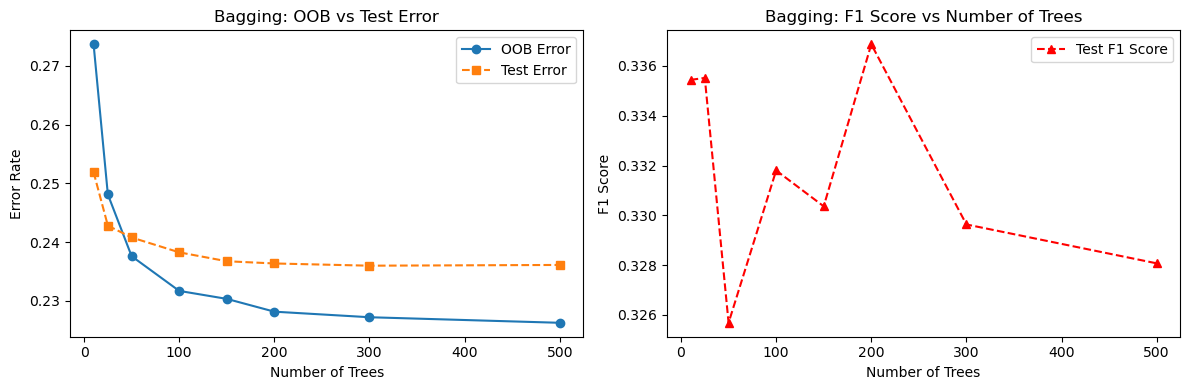

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ── Left plot: Error rates 
ax1.plot(n_est_range, bag_oob_errs,
         marker='o', label='OOB Error')
ax1.plot(n_est_range, [1 - a for a in bag_test_accs],
         marker='s', ls='--', label='Test Error')
ax1.set_xlabel('Number of Trees')
ax1.set_ylabel('Error Rate')
ax1.set_title('Bagging: OOB vs Test Error')
ax1.legend()

# ── Right plot: F1 Score 

ax2.plot(n_est_range, bag_test_f1,
         marker='^', color='red', ls='--', label='Test F1 Score')
ax2.set_xlabel('Number of Trees')
ax2.set_ylabel('F1 Score')
ax2.set_title('Bagging: F1 Score vs Number of Trees')
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
# Final Bagging model with best n_stimators

final_bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=SEED),
    n_estimators= best_n_bag,
    oob_score=True,
    random_state=SEED,
    n_jobs=-1
)
final_bag.fit(X_train, y_train)
bag_y_pred = final_bag.predict(X_test)
bag_acc = accuracy_score(y_test, bag_y_pred)

print(f"Bagging OOB accuracy: {final_bag.oob_score_:.4f}")
print(f"Bagin test accuracy: {bag_acc:.4f}")
print()
print(classification_report(y_test, bag_y_pred, target_names=['Not Popular', 'Popular']))

Bagging OOB accuracy: 0.7718
Bagin test accuracy: 0.7636

              precision    recall  f1-score   support

 Not Popular       0.83      0.89      0.86      6285
     Popular       0.40      0.29      0.34      1643

    accuracy                           0.76      7928
   macro avg       0.61      0.59      0.60      7928
weighted avg       0.74      0.76      0.75      7928



---
## 5. Random Forest

### 5.1 What Is a Random Forest?

**Random Forest** is an extension of bagging with one key addition: at each split, only a **random subset of $m$ features** is considered (not all $p$). This **decorrelates** the trees.

**Why decorrelation matters:**  
In bagging, all trees tend to use the same strong predictors at the top splits, making them correlated. If trees are correlated with correlation $\rho$, the variance of their average is:

$$\text{Var}(\bar{T}) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$$

As $B \to \infty$, this converges to $\rho \sigma^2$ — not zero! Reducing $\rho$ by limiting features gives further variance reduction.

**Rule of thumb for $m$:**
- Classification: $m = \sqrt{p}$ (e.g., $\sqrt{58} \approx 8$)
- Regression: $m = p/3$

**Additional benefits:**
- **Variable importance** — easy to compute from how much each feature reduces impurity across all trees  
- **OOB error** — free internal validation, no separate CV needed  
- **Parallelizable** — trees are independent

In [18]:
# Random Forest: tune max_features and n_estimaros
# max_features controls how manu features are considered in each split.
# We test: 'sqrt', 'log2', and a few integer values.

p = X_train.shape[1]    # Number of features
mf_options = ['sqrt', 'log2', int(p*0.3), int(p*0.5)]
rf_results = []

for mf in mf_options:
    rf = RandomForestClassifier(
        class_weight='balanced_subsample',
        n_estimators=100,
        max_features=mf,
        oob_score=True,
        random_state=SEED,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    rf_y_pred = rf.predict(X_test)
    rf_test_acc = accuracy_score(y_test, rf_y_pred)
    rf_test_f1 = f1_score(y_test, rf_y_pred)
    rf_results.append(
        {'max_features': mf,
         'oob_score': rf.oob_score_,
         'rf_test_accuracy': rf_test_acc,
         'rf_f1_scores': rf_test_f1}
    )
    print(f"max_features={str(mf):6s}  OOB={rf.oob_score_:.4f}  Test_acc={rf_test_acc:.4f}  Test_f1={rf_test_f1:.4f}")
rf_df      = pd.DataFrame(rf_results)
best_mf    = rf_df.loc[rf_df['rf_f1_scores'].idxmax(), 'max_features']
print(f"\nBest max_features: {best_mf}")

max_features=sqrt    OOB=0.7960  Test_acc=0.7915  Test_f1=0.0516
max_features=log2    OOB=0.7959  Test_acc=0.7923  Test_f1=0.0496
max_features=17      OOB=0.7952  Test_acc=0.7925  Test_f1=0.0836
max_features=29      OOB=0.7955  Test_acc=0.7921  Test_f1=0.0935

Best max_features: 29


In [19]:
# Now we tune n_estimators with the max_features
n_est_range_rf = [50, 100, 150, 200, 300, 500]
rf_n_results = []

for n in n_est_range_rf:
    rf = RandomForestClassifier(
         class_weight='balanced_subsample',
        n_estimators=n,
        max_features=best_mf,
        random_state=SEED,
        oob_score=True,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    rf_test_acc = accuracy_score(y_test, rf.predict(X_test))
    rf_test_f1 = f1_score(y_test, rf.predict(X_test))
    rf_n_results.append({
        'n_estimators': n,
        'oob_accu': rf.oob_score_,
        'test_acc': rf_test_acc,
        'F1_score': rf_test_f1
    }
    )
rf_n_df   = pd.DataFrame(rf_n_results)
best_n_rf = rf_n_df.loc[rf_n_df['F1_score'].idxmax(), 'n_estimators']
print(f"\nBest n_estimators: {best_n_rf}")


Best n_estimators: 150


In [20]:
# ── Final Random Forest 
final_rf = RandomForestClassifier(
    class_weight='balanced_subsample',
    n_estimators=int(best_n_rf),
    max_features=best_mf,
    oob_score=True,
    random_state=SEED,
    n_jobs=-1
)
final_rf.fit(X_train, y_train)
y_pred_rf = final_rf.predict(X_test)
rf_acc    = accuracy_score(y_test, y_pred_rf)
rf_f1     = f1_score(y_test, y_pred_rf)

print(f"Random Forest OOB accuracy : {final_rf.oob_score_:.4f}")
print(f"Random Forest test accuracy: {rf_acc:.4f}")
print(f"Random Forest F1 score: {rf_f1:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Not Popular', 'Popular']))

Random Forest OOB accuracy : 0.7966
Random Forest test accuracy: 0.7929
Random Forest F1 score: 0.0948

              precision    recall  f1-score   support

 Not Popular       0.80      0.99      0.88      6285
     Popular       0.50      0.05      0.09      1643

    accuracy                           0.79      7928
   macro avg       0.65      0.52      0.49      7928
weighted avg       0.74      0.79      0.72      7928



## 5.2 Variable Importance

Random forests provide a natural **variable importance** measure. For each feature, we average the reduction in Gini impurity it causes across all splits and all trees. Features that appear higher in more trees and reduce impurity more get higher scores.

This tells us which article characteristics matter most for predicting virality — and directly answers the case study requirement for a variable importance plot.

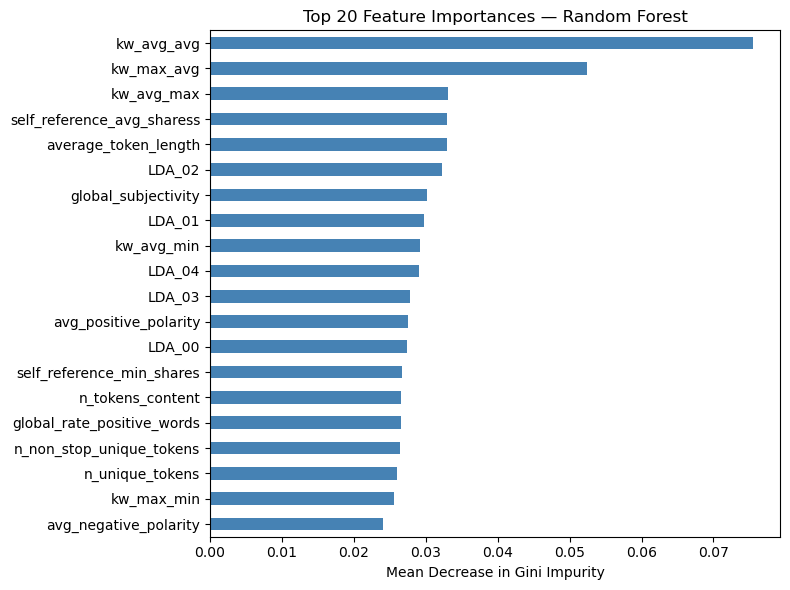

Top 10 most important features:
kw_avg_avg                    0.075481
kw_max_avg                    0.052364
kw_avg_max                    0.033042
self_reference_avg_sharess    0.033000
average_token_length          0.033000
LDA_02                        0.032182
global_subjectivity           0.030129
LDA_01                        0.029694
kw_avg_min                    0.029234
LDA_04                        0.029039


In [21]:
# ── Variable Importance Plot ──────────────────────────────────────────────────
# feature_importances_ gives the mean decrease in Gini impurity per feature,
# averaged across all trees. Higher = more important.

importances = pd.Series(final_rf.feature_importances_, index=X_train.columns)
top20       = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title('Top 20 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

print('Top 10 most important features:')
print(top20.head(10).to_string())

---
## 6. Final Comparison & MSPE

**MSPE (Mean Square Prediction Error)** for a binary classifier simplifies to the misclassification rate:

$$\text{MSPE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = 1 - \text{accuracy}$$

Since $y_i, \hat{y}_i \in \{0, 1\}$, a wrong prediction always contributes $(1-0)^2 = 1$ and a correct one contributes $0$.

We report both **MSPE** (lower is better) and **Test F1 on the Popular class** (higher is better) because accuracy alone is misleading given our class imbalance.

### Discussion

**Single tree vs ensemble methods:**

| | Classification Tree | Bagging | Random Forest |
|---|---|---|---|
| Variance | High | Medium | Low |
| Bias | Low | Low | Low |
| Interpretability | High | None | None |
| Training time | Fast | Medium | Medium |
| Handles imbalance | Poorly | With `class_weight` | With `balanced_subsample` |

**Advantages of ensemble methods:**
- Bagging reduces variance by averaging many trees — a single tree is unstable, small changes in data produce very different models
- Random Forest further decorrelates trees by subsampling features at each split, reducing the $\rho\sigma^2$ variance floor that limits plain bagging
- Both provide OOB error as free internal validation — no separate CV needed

**Disadvantages of ensemble methods:**
- Complete loss of interpretability — you cannot visualise or explain a forest of 200 trees the way you can a single pruned tree
- Slower to train and predict
- Class imbalance requires extra care — `balanced_subsample` in Random Forest behaves differently from `class_weight='balanced'` in a single tree
- Variable importance scores can be biased toward high-cardinality features

In [34]:
# ── Final comparison table ────────────────────────────────────────────────────
# We collect predictions from all fitted models and compute MSPE and F1.
# bag_y_pred       -> from final_bag             (Bagging)
# y_pred_rf        -> from final_rf              (Random Forest)
# y_pred_post      -> from post_pruned_tree      (Post-Pruned ccp_alpha)
# rand_y_predicted -> from rand_search           (RandomizedSearchCV balanced)

models = [
    {'Model': 'Unpruned Tree',
     'Test Acc': round(baseline_acc, 4),
     'MSPE'    : round(1 - baseline_acc, 4),
     'Test F1' : round(f1_score(y_test, baseline_tree.predict(X_test)), 4)},

    {'Model': 'GridSearchCV (pre-pruned)',
     'Test Acc': round(grid_search.best_estimator_.score(X_test, y_test), 4),
     'MSPE'    : round(1 - grid_search.best_estimator_.score(X_test, y_test), 4),
     'Test F1' : round(f1_score(y_test, grid_search.predict(X_test)), 4)},

    {'Model': 'RandomizedSearchCV (balanced)',
     'Test Acc': round(rand_test_acc, 4),
     'MSPE'    : round(1 - rand_test_acc, 4),
     'Test F1' : round(rand_test_f1, 4)},

    {'Model': 'Post-Pruned (ccp_alpha)',
     'Test Acc': round(post_acc, 4),
     'MSPE'    : round(1 - post_acc, 4),
     'Test F1' : round(post_f1, 4)},

    {'Model': 'Bagging',
     'Test Acc': round(bag_acc, 4),
     'MSPE'    : round(1 - bag_acc, 4),
     'Test F1' : round(f1_score(y_test, bag_y_pred), 4)},

    {'Model': 'Random Forest',
     'Test Acc': round(rf_acc, 4),
     'MSPE'    : round(1 - rf_acc, 4),
     'Test F1' : round(rf_f1, 4)},
]

final_df = pd.DataFrame(models)
print(final_df.to_string(index=False))

                        Model  Test Acc   MSPE  Test F1
                Unpruned Tree    0.7007 0.2993   0.2998
    GridSearchCV (pre-pruned)    0.7928 0.2072   0.0000
RandomizedSearchCV (balanced)    0.6057 0.3943   0.4124
      Post-Pruned (ccp_alpha)    0.6136 0.3864   0.4180
                      Bagging    0.7636 0.2364   0.3369
                Random Forest    0.7929 0.2071   0.0948


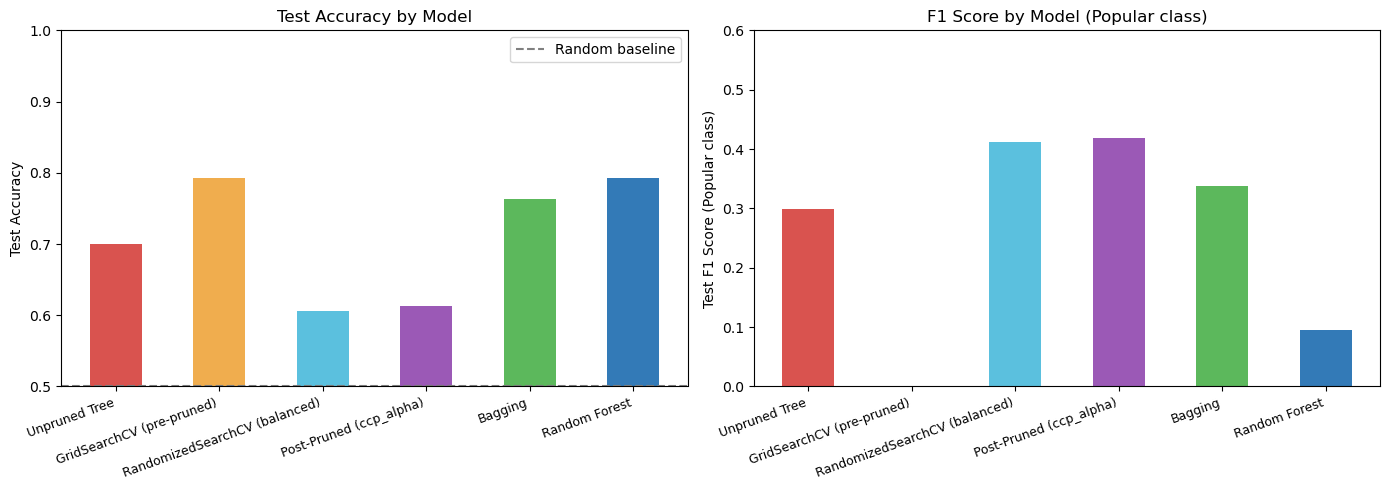

In [28]:
# ── Bar chart: Test Accuracy and F1 side by side ─────────────────────────────
x      = np.arange(len(final_df))
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#9b59b6', '#5cb85c', '#337ab7']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Test Accuracy
axes[0].bar(x, final_df['Test Acc'], width=0.5, color=colors)
axes[0].axhline(0.5, ls='--', color='gray', label='Random baseline')
axes[0].set_xticks(x)
axes[0].set_xticklabels(final_df['Model'], rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Test Accuracy by Model')
axes[0].legend()

# Right: Test F1 on Popular class
axes[1].bar(x, final_df['Test F1'], width=0.5, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(final_df['Model'], rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Test F1 Score (Popular class)')
axes[1].set_ylim(0, 0.6)
axes[1].set_title('F1 Score by Model (Popular class)')

plt.tight_layout()
plt.show()

In [30]:
from sklearn.utils import resample

# ----- Separate classes -----

X_train_maj = X_train[y_train == 0]     # Not popular : 25,280
X_train_min = X_train[y_train == 1]     # popular     :  6,436

Y_train_maj = y_train[y_train == 0]
Y_train_min = y_train[y_train == 1]

#  Under sample both classes to 6000
X_maj_under, Y_maj_under = resample(
    X_train_maj, Y_train_maj, 
    replace= False,     # Not duplicates - just pick a randome subset
    n_samples=6000, 
    random_state=SEED
    )

X_min_under, Y_min_under = resample(
    X_train_min, Y_train_min,
    replace=False,
    n_samples=6000,
    random_state=SEED
)
# Combine into balanced training set

X_train_balanced = pd.concat([X_maj_under, X_min_under])
Y_train_balanced = pd.concat([Y_maj_under, Y_min_under])

print(f"Not popular: {(Y_train_balanced ==0).sum()}  Popular: {(Y_train_balanced == 1).sum()}")
print(f"\nNew training set size: {X_train_balanced.shape[0]}")


Not popular: 6000  Popular: 6000

New training set size: 12000


In [32]:
# ── Defining models with their tuned parameters
# No class_weight needed — data is already balanced
models_to_run = {
    'Unpruned Tree'       : DecisionTreeClassifier(random_state=SEED),
    'GridSearchCV'        : DecisionTreeClassifier(**grid_search.best_params_, random_state=SEED),
    'RandomizedSearchCV'  : DecisionTreeClassifier(**rand_search.best_params_, random_state=SEED),
    'Post-Pruned (alpha)' : DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=SEED),
    'Bagging'             : BaggingClassifier(
                                estimator=DecisionTreeClassifier(max_depth=15, random_state=SEED),
                                n_estimators=best_n_bag,
                                random_state=SEED, n_jobs=-1),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=int(best_n_rf),
                                max_features=best_mf,
                                random_state=SEED, n_jobs=-1),
}

# ── Fit on balanced data, evaluate on original test set ───────────────────────
rows = []
for name, model in models_to_run.items():
    model.fit(X_train_balanced, Y_train_balanced)        # ← balanced training data
    y_pred   = model.predict(X_test)           # ← original test set
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred)
    rows.append({
        'Model'   : name,
        'Test Acc': round(test_acc, 4),
        'MSPE'    : round(1 - test_acc, 4),
        'Test F1' : round(test_f1, 4)
    })

model_bal_df = pd.DataFrame(rows)
print(model_bal_df.to_string(index=False))

              Model  Test Acc   MSPE  Test F1
      Unpruned Tree    0.5574 0.4426   0.3534
       GridSearchCV    0.6298 0.3702   0.4053
 RandomizedSearchCV    0.6119 0.3881   0.4059
Post-Pruned (alpha)    0.5744 0.4256   0.3712
            Bagging    0.6435 0.3565   0.4353
      Random Forest    0.6476 0.3524   0.4401


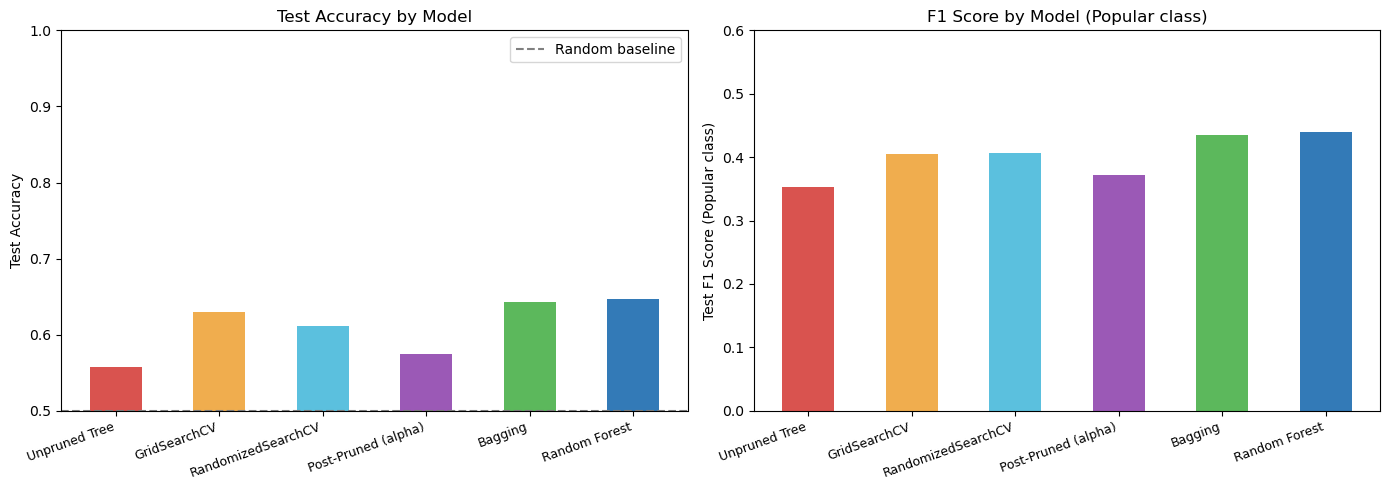

In [35]:
# ── Bar chart: Test Accuracy and F1 side by side ─────────────────────────────
x      = np.arange(len(model_bal_df))
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#9b59b6', '#5cb85c', '#337ab7']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Test Accuracy
axes[0].bar(x, model_bal_df['Test Acc'], width=0.5, color=colors)
axes[0].axhline(0.5, ls='--', color='gray', label='Random baseline')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_bal_df['Model'], rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Test Accuracy by Model')
axes[0].legend()

# Right: Test F1 on Popular class
axes[1].bar(x, model_bal_df['Test F1'], width=0.5, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_bal_df['Model'], rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Test F1 Score (Popular class)')
axes[1].set_ylim(0, 0.6)
axes[1].set_title('F1 Score by Model (Popular class)')

plt.tight_layout()
plt.show()